<a href="https://colab.research.google.com/github/senthil-kumar-7/food-delivery-analytics-project/blob/main/food_delivery_analytics_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. Original Dataset Preview ---
   Order_ID Item_Name Order_Time  Price
0         1   Biryani      12:30    150
1         2     Pizza      19:00    250
2         3   Biryani      13:00    150
3         4      Dosa      08:30     50
4         5    Burger      19:30    120


--- 2. Cleaned Dataset (Missing values removed) ---
   Order_ID Item_Name Order_Time  Price
0         1   Biryani      12:30    150
1         2     Pizza      19:00    250
2         3   Biryani      13:00    150
3         4      Dosa      08:30     50
4         5    Burger      19:30    120


--- 3. Popular Dishes Count ---
Item_Name
Biryani    5
Pizza      3
Dosa       3
Burger     2
Noodles    1
Name: count, dtype: int64


--- 4. Peak Order Times (By Hour) ---
Hour
8     2
9     1
12    2
13    3
18    1
19    3
20    2
Name: count, dtype: int64




/tmp/ipykernel_3667/4276460223.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'Hour'] = pd.to_datetime(df_cleaned['Order_Time'], format='%H:%M').dt.hour


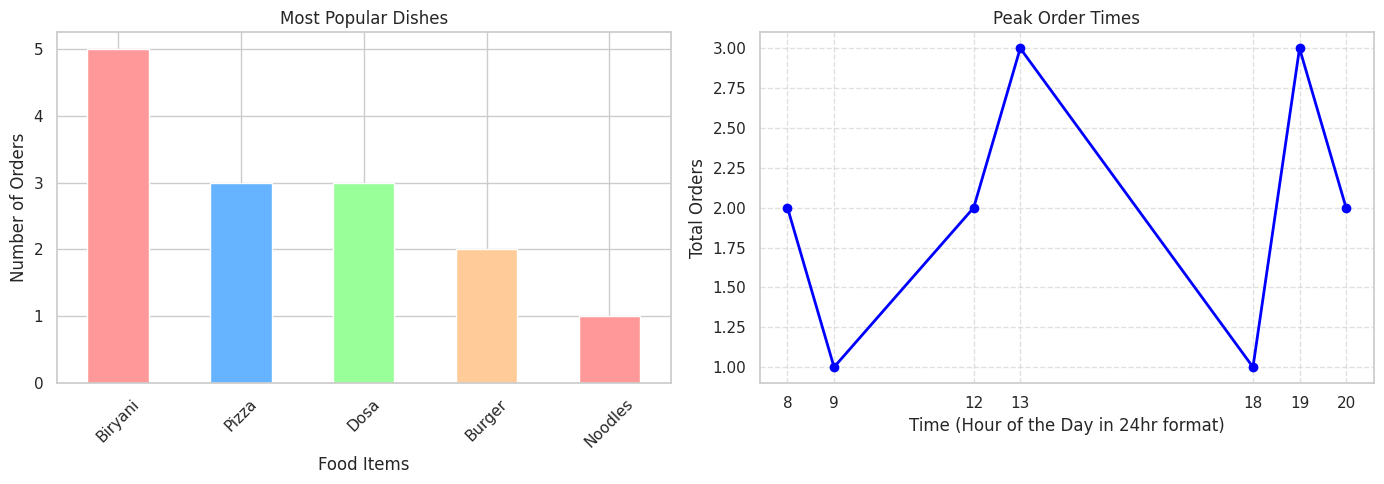

In [3]:
# Thevaiyana libraries-a import pandrom
import pandas as pd
import matplotlib.pyplot as plt

# 1. DATA Uruvakuthal (Sample Data creation for practice)
# Real project-la neenga CSV file-a load pannikalam
data = {
    'Order_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'Item_Name': ['Biryani', 'Pizza', 'Biryani', 'Dosa', 'Burger', 'Pizza', 'Biryani', 'Dosa', 'Noodles', 'Biryani', None, 'Pizza', 'Burger', 'Biryani', 'Dosa'],
    'Order_Time': ['12:30', '19:00', '13:00', '08:30', '19:30', '20:00', '13:15', '09:00', '20:30', '12:45', '14:00', '19:45', '18:30', '13:30', '08:45'],
    'Price': [150, 250, 150, 50, 120, 250, 150, 50, 100, 150, 200, 250, 120, 150, 50]
}
df = pd.DataFrame(data)

print("--- 1. Original Dataset Preview ---")
print(df.head())
print("\n")

# 2. DATA CLEANING
# Dataset-la 'None' (missing values) irukka nu check panni remove pandrom
df_cleaned = df.dropna()
print("--- 2. Cleaned Dataset (Missing values removed) ---")
print(df_cleaned.head())
print("\n")

# 3. DATA ANALYSIS: Most Popular Dishes
# Entha food item adhigama order aagirukku nu count pandrom
popular_dishes = df_cleaned['Item_Name'].value_counts()
print("--- 3. Popular Dishes Count ---")
print(popular_dishes)
print("\n")

# 4. DATA ANALYSIS: Peak Order Time
# Order time-a vechu entha manineram (hour) adhigama order varuthu nu analyze pandrom
df_cleaned.loc[:, 'Hour'] = pd.to_datetime(df_cleaned['Order_Time'], format='%H:%M').dt.hour
peak_hours = df_cleaned['Hour'].value_counts().sort_index()
print("--- 4. Peak Order Times (By Hour) ---")
print(peak_hours)
print("\n")

# 5. VISUALIZATION (Charts / Dashboard)
# Bar chart matrum Line chart uruvakuthal
plt.figure(figsize=(14, 5))

# Chart 1: Bar Chart for Popular Dishes
plt.subplot(1, 2, 1)
popular_dishes.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Most Popular Dishes')
plt.xlabel('Food Items')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Chart 2: Line Chart for Peak Order Times
plt.subplot(1, 2, 2)
peak_hours.plot(kind='line', marker='o', color='blue', linewidth=2)
plt.title('Peak Order Times')
plt.xlabel('Time (Hour of the Day in 24hr format)')
plt.ylabel('Total Orders')
plt.xticks(peak_hours.index)
plt.grid(True, linestyle='--', alpha=0.6)

# Charts-a display pandrathu
plt.tight_layout()
plt.show()